In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0


In [4]:
# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


In [5]:
# ----------------------------
# DATA AUGMENTATION
# ----------------------------
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train)

In [6]:
# ----------------------------
# BUILD CNN MODEL
# ----------------------------
model = models.Sequential()


In [7]:
# Block 1
model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(32, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Block 2
model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(64, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))


In [9]:
# Block 3
model.add(layers.Conv2D(128, (3,3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Fully Connected Layers
model.add(layers.Flatten())

model.add(layers.Dense(128))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(10, activation='softmax'))


In [10]:
# ----------------------------
# COMPILE MODEL
# ----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
# ----------------------------
# TRAIN MODEL
# ----------------------------
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 415s 530ms/step - accuracy: 0.7617 - loss: 0.6961 - val_accuracy: 0.7384 - val_loss: 0.8085
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 415s 530ms/step - accuracy: 0.7685 - loss: 0.6827 - val_accuracy: 0.7684 - val_loss: 0.7089
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 418s 534ms/step - accuracy: 0.7721 - loss: 0.6658 - val_accuracy: 0.7508 - val_loss: 0.7563
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 420s 538ms/step - accuracy: 0.7748 - loss: 0.6649 - val_accuracy: 0.7948 - val_loss: 0.5997
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 417s 533ms/step - accuracy: 0.7761 - loss: 0.6571 - val_accuracy: 0.7871 - val_loss: 0.6298
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 418s 535ms/step - accuracy: 0.7762 - loss: 0.6516 - val_accuracy: 0.7454 - val_loss: 0.7435
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 416s 532ms/step - accuracy: 0.7816 - loss: 0.6400 - val_accuracy: 0.7867 - val_loss: 0.6302
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 446s 538ms/step - accuracy: 0.7839 -

In [14]:
# ----------------------------
# EVALUATE MODEL
# ----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7935 - loss: 0.6480
Test Accuracy: 0.7935000061988831


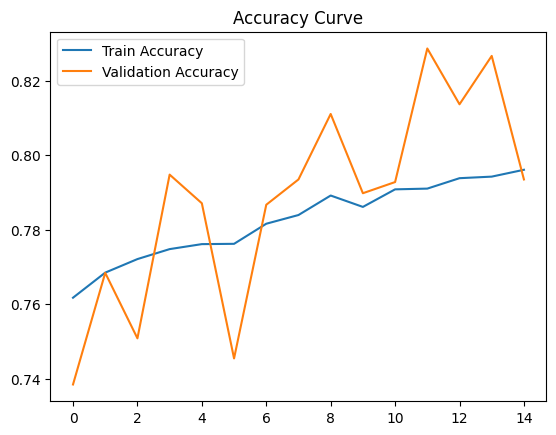

In [15]:
# ----------------------------
# PLOT TRAINING RESULTS
# ----------------------------
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

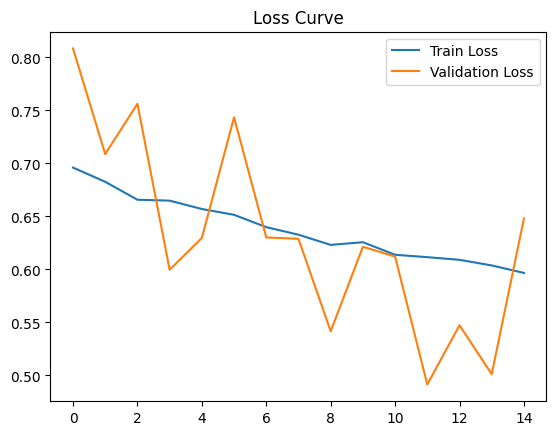

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()